# Regresion en Machine Learning: prediccion de precios de vivienda

Este notebook desarrolla un problema completo de **regresion supervisada** usando Python y scikit-learn. El objetivo es estimar el valor mediano de viviendas en distritos de California a partir de variables geograficas, demograficas y socioeconomicas.

La idea no es solo entrenar modelos, sino entender cada decision tecnica: exploracion de datos, preparacion, seleccion de modelos, evaluacion e interpretacion.

## 1. Introduccion al problema

Queremos predecir el valor numerico **`median_house_value`**, que representa el valor mediano de las viviendas en un distrito de California.

Este es un problema de **regresion** porque la variable objetivo es numerica continua. No queremos asignar una categoria como "caro" o "barato"; queremos estimar un valor monetario.

Variable objetivo:

- `median_house_value`: valor mediano de las viviendas del distrito.

Variables predictoras:

- Variables geograficas: `longitude`, `latitude`, `ocean_proximity`.
- Variables de vivienda: `housing_median_age`, `total_rooms`, `total_bedrooms`, `households`.
- Variables poblacionales y economicas: `population`, `median_income`.

Contexto del dataset:

Usaremos el dataset de vivienda de California disponible publicamente en GitHub: https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv. Es un dataset clasico para ensenar regresion porque combina variables numericas, una variable categorica, valores faltantes y una variable objetivo interpretable.

## 2. Carga de librerias

Primero verificamos que las dependencias necesarias esten instaladas. Si alguna falta, la siguiente celda la instala con `pip`. Esto ayuda a que el notebook pueda ejecutarse desde cero en un entorno nuevo.

Luego importaremos las librerias necesarias:

- `pandas` y `numpy` para manipulacion de datos.
- `matplotlib` y `seaborn` para visualizacion.
- `scikit-learn` para preparar datos, entrenar modelos y evaluarlos.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Instalando dependencias faltantes:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Todas las dependencias necesarias estan instaladas.")

Todas las dependencias necesarias estan instaladas.


Importamos las librerias. Tambien definimos una semilla aleatoria para que la division de datos y los resultados sean reproducibles.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

## 3. Carga del dataset

Cargamos el archivo CSV directamente desde una fuente publica en internet. Esto permite ejecutar el notebook sin descargar manualmente ningun archivo.

Luego mostramos las primeras filas para reconocer las columnas principales y el formato general de los datos.

In [3]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Revisamos la estructura de las columnas. `info()` muestra el numero de registros no nulos, los tipos de datos y el uso de memoria. Esto ayuda a identificar variables numericas, categoricas y posibles valores faltantes.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Columnas principales:

- `longitude` y `latitude`: ubicacion geografica del distrito.
- `housing_median_age`: antiguedad mediana de las viviendas.
- `total_rooms` y `total_bedrooms`: numero total de habitaciones y dormitorios en el distrito.
- `population`: poblacion del distrito.
- `households`: numero de hogares.
- `median_income`: ingreso mediano, expresado en decenas de miles de dolares aproximadamente.
- `ocean_proximity`: cercania al oceano, variable categorica.
- `median_house_value`: valor mediano de vivienda, nuestra variable objetivo.

## 4. Analisis exploratorio de datos

El analisis exploratorio permite entender la calidad y forma de los datos antes de modelar. En regresion, nos interesa especialmente la distribucion de la variable objetivo, la relacion entre predictores y objetivo, los valores faltantes y posibles valores extremos.

In [5]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.dtypes

Filas: 20640
Columnas: 10


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Revisamos valores nulos. Si una columna tiene datos faltantes, no conviene eliminarlos automaticamente sin pensar: puede perderse informacion. En este caso, usaremos imputacion dentro del pipeline de modelado.

In [6]:
df.isna().sum().sort_values(ascending=False)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Las estadisticas descriptivas resumen media, dispersion, minimos, maximos y cuartiles. Son utiles para detectar variables en escalas diferentes y posibles valores extremos. Por ejemplo, `population` y `total_rooms` pueden tener rangos muy amplios.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


Analizamos la distribucion de la variable objetivo. Esto nos ayuda a saber si los precios estan concentrados, sesgados o truncados. En este dataset es comun observar una acumulacion en el valor maximo, lo cual sugiere que algunos precios fueron limitados por un techo de registro.

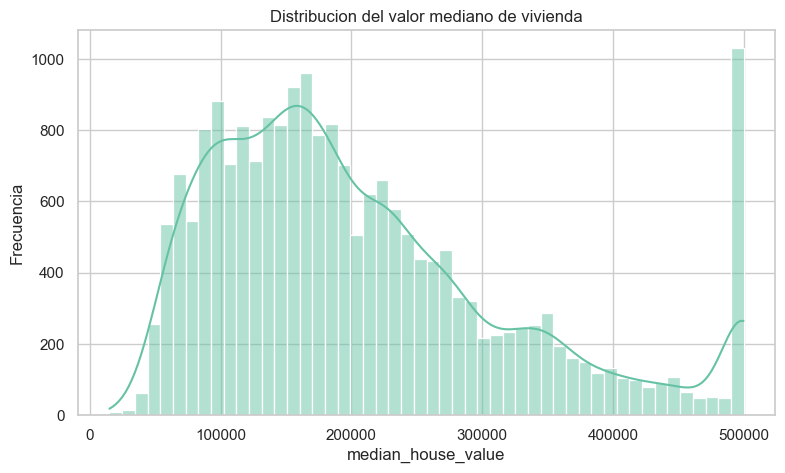

In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("Distribucion del valor mediano de vivienda")
plt.xlabel("median_house_value")
plt.ylabel("Frecuencia")
plt.show()

Revisamos la variable categorica `ocean_proximity`. Esta variable puede ser importante porque la cercania al oceano suele estar relacionada con el precio de vivienda. Como los modelos lineales no trabajan directamente con texto, mas adelante la codificaremos con One-Hot Encoding.

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

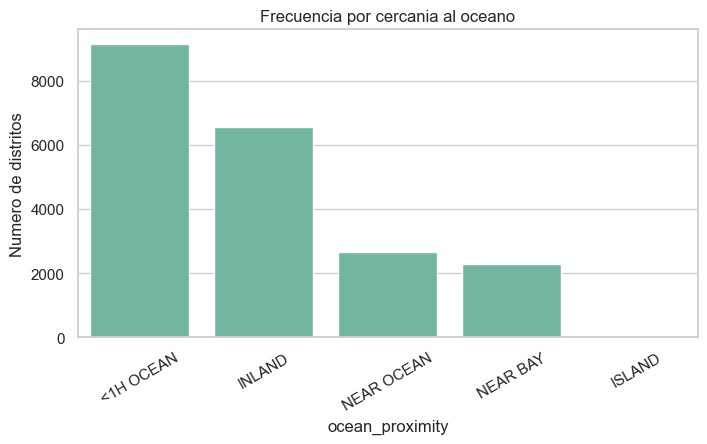

In [9]:
display(df["ocean_proximity"].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="ocean_proximity", order=df["ocean_proximity"].value_counts().index)
plt.title("Frecuencia por cercania al oceano")
plt.xlabel("ocean_proximity")
plt.ylabel("Numero de distritos")
plt.xticks(rotation=30)
plt.show()

Comparamos precios segun cercania al oceano. Un boxplot permite observar medianas, dispersion y valores extremos por categoria.

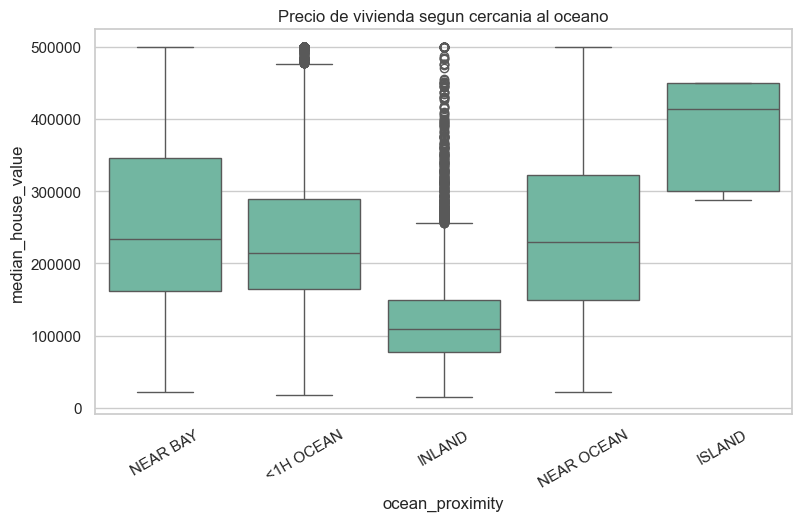

In [10]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value")
plt.title("Precio de vivienda segun cercania al oceano")
plt.xlabel("ocean_proximity")
plt.ylabel("median_house_value")
plt.xticks(rotation=30)
plt.show()

Calculamos correlaciones entre variables numericas. La correlacion mide asociacion lineal. No implica causalidad, pero puede mostrar predictores relevantes. En este dataset suele destacar `median_income` como una variable muy relacionada con el precio de vivienda.

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

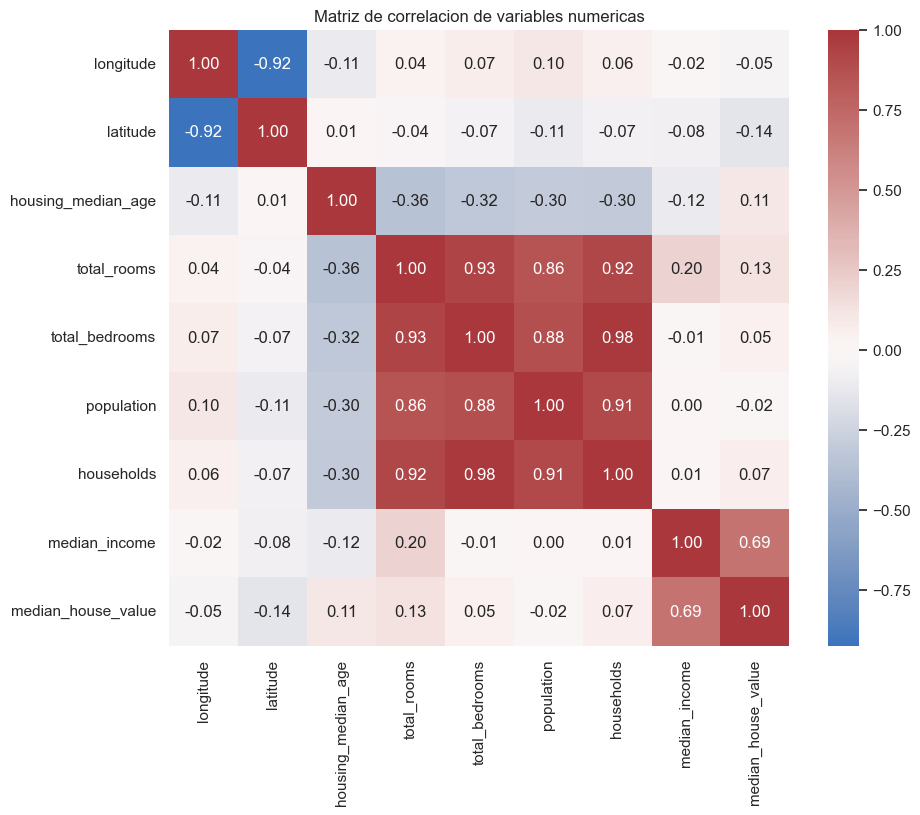

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["median_house_value"].sort_values(ascending=False)
display(correlations)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Matriz de correlacion de variables numericas")
plt.show()

Visualizamos algunas relaciones importantes con la variable objetivo. El grafico de dispersion entre `median_income` y `median_house_value` permite ver si a mayores ingresos medianos suelen asociarse mayores precios de vivienda.

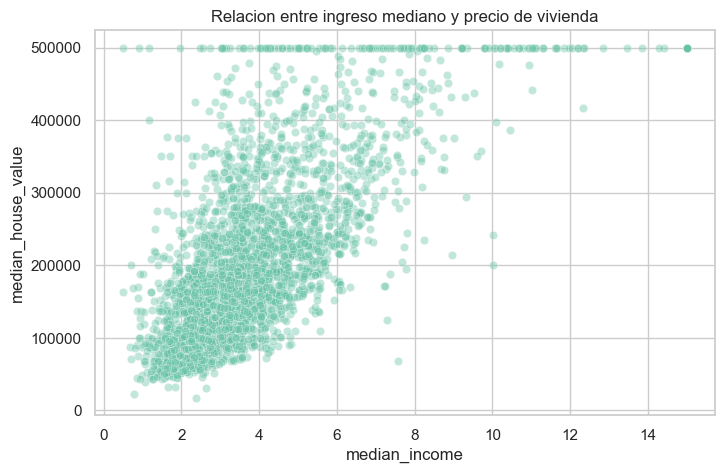

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x="median_income", y="median_house_value", alpha=0.4)
plt.title("Relacion entre ingreso mediano y precio de vivienda")
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.show()

Tambien graficamos la ubicacion geografica. Cada punto representa un distrito. El color indica el valor mediano de vivienda. Esto permite observar patrones espaciales, especialmente precios mas altos en zonas costeras o metropolitanas.

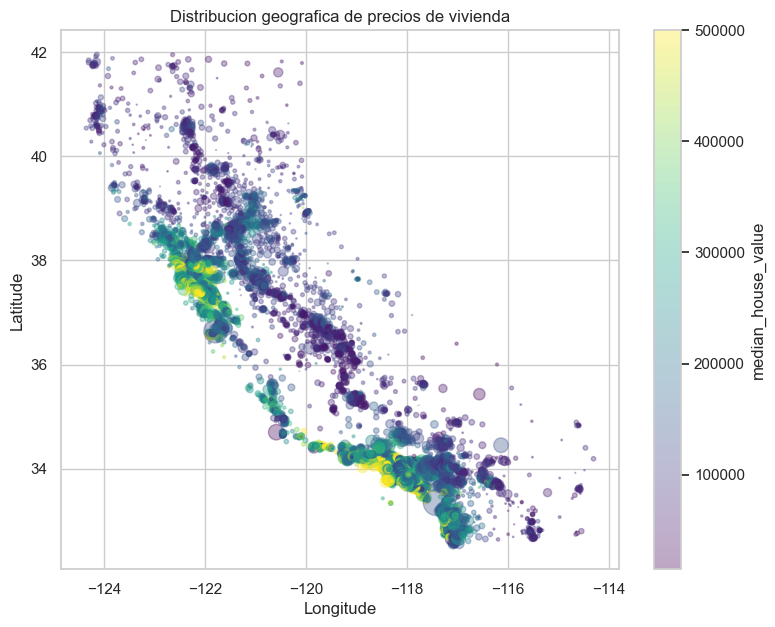

In [13]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    alpha=0.35,
    s=df["population"] / 100,
)
plt.colorbar(scatter, label="median_house_value")
plt.title("Distribucion geografica de precios de vivienda")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 5. Preparacion de datos

Antes de modelar, separamos la variable objetivo de las variables predictoras. Luego dividimos los datos en entrenamiento y prueba.

Tambien crearemos algunas variables derivadas simples. Por ejemplo, `rooms_per_household` puede ser mas informativa que el total de habitaciones, porque ajusta el tamano del distrito por numero de hogares.

In [14]:
df_model = df.copy()

df_model["rooms_per_household"] = df_model["total_rooms"] / df_model["households"]
df_model["bedrooms_per_room"] = df_model["total_bedrooms"] / df_model["total_rooms"]
df_model["population_per_household"] = df_model["population"] / df_model["households"]

df_model.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


Definimos `X` e `y`. `X` contiene las variables predictoras; `y` contiene el precio que queremos predecir.

In [15]:
X = df_model.drop(columns="median_house_value")
y = df_model["median_house_value"]

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,6.281853,0.172096,2.181467


Dividimos en entrenamiento y prueba. El conjunto de entrenamiento se usa para ajustar los modelos; el conjunto de prueba se reserva para evaluar como generalizan ante datos no vistos.

Usamos 80% para entrenamiento y 20% para prueba.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Tamanos:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Tamanos:
X_train: (16512, 12)
X_test:  (4128, 12)
y_train: (16512,)
y_test:  (4128,)


Identificamos columnas numericas y categoricas. Esta separacion permite aplicar transformaciones distintas a cada tipo de variable:

- Numericas: imputacion con mediana y escalado.
- Categoricas: imputacion con valor mas frecuente y One-Hot Encoding.

El escalado es especialmente importante para Ridge, porque su regularizacion depende de la magnitud de los coeficientes.

In [17]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numericas:", numeric_features)
print("Variables categoricas:", categorical_features)

Variables numericas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Variables categoricas: ['ocean_proximity']


Construimos un preprocesador con `ColumnTransformer`. Esta herramienta permite aplicar pasos diferentes por tipo de columna dentro de un mismo pipeline.

Usar pipelines reduce el riesgo de fuga de informacion, porque las imputaciones, escalados y codificaciones se aprenden solo con el conjunto de entrenamiento.

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

## 6. Modelado

Entrenaremos dos modelos de regresion:

### Regresion lineal

La regresion lineal busca una combinacion lineal de las variables predictoras para estimar el valor objetivo. Es un modelo base muy importante porque es interpretable y sirve como punto de comparacion.

Hiperparametros principales:

- `fit_intercept`: indica si el modelo aprende un intercepto.
- `positive`: restringe coeficientes a valores positivos si se activa.

En este notebook usaremos la configuracion por defecto, porque queremos una linea base simple.

### Ridge Regression

Ridge es una regresion lineal con regularizacion L2. Penaliza coeficientes demasiado grandes y puede mejorar la generalizacion cuando hay variables correlacionadas o ruido.

Hiperparametro principal:

- `alpha`: controla la fuerza de la regularizacion. Valores mas altos penalizan mas los coeficientes.

Configuraremos `alpha=10.0` como una regularizacion moderada. Tambien usamos `random_state` cuando el algoritmo lo permite para reproducibilidad.

In [19]:
linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE)),
])

## 7. Entrenamiento

Entrenar un modelo de regresion significa ajustar sus parametros internos para minimizar el error entre los valores reales y los valores predichos en el conjunto de entrenamiento.

En la regresion lineal y Ridge, el modelo aprende coeficientes asociados a cada variable.

In [20]:
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


## 8. Evaluacion

Evaluaremos los modelos con metricas comunes de regresion:

- **MAE**: error absoluto medio. Indica cuanto se equivoca el modelo en promedio, en las mismas unidades del precio.
- **MSE**: error cuadratico medio. Penaliza mas los errores grandes porque eleva los errores al cuadrado.
- **RMSE**: raiz del MSE. Vuelve a las unidades originales del precio y tambien penaliza errores grandes.
- **R²**: proporcion de variabilidad del precio explicada por el modelo. Valores mas cercanos a 1 indican mejor ajuste.

En precios de vivienda, MAE y RMSE pueden interpretarse como errores monetarios aproximados.

In [21]:
def regression_metrics(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return {
        "modelo": name,
        "train_rmse": train_rmse,
        "test_mae": test_mae,
        "test_mse": test_mse,
        "test_rmse": test_rmse,
        "train_r2": train_r2,
        "test_r2": test_r2,
    }, test_pred

linear_metrics, linear_pred = regression_metrics(
    "Regresion lineal", linear_model, X_train, y_train, X_test, y_test
)

ridge_metrics, ridge_pred = regression_metrics(
    "Ridge", ridge_model, X_train, y_train, X_test, y_test
)

results = pd.DataFrame([linear_metrics, ridge_metrics]).set_index("modelo")
results.round(2)

,train_rmse,test_mae,test_mse,test_rmse,train_r2,test_r2
modelo,,,,,,
Regresion lineal,67593.21,49645.49,4.778547e+09,69127.04,0.66,0.64
Ridge,67609.46,49667.73,4.784623e+09,69170.97,0.66,0.63


Graficamos valores reales contra valores predichos. Si el modelo fuera perfecto, todos los puntos caerian sobre la linea diagonal. Desviaciones grandes indican errores de prediccion.

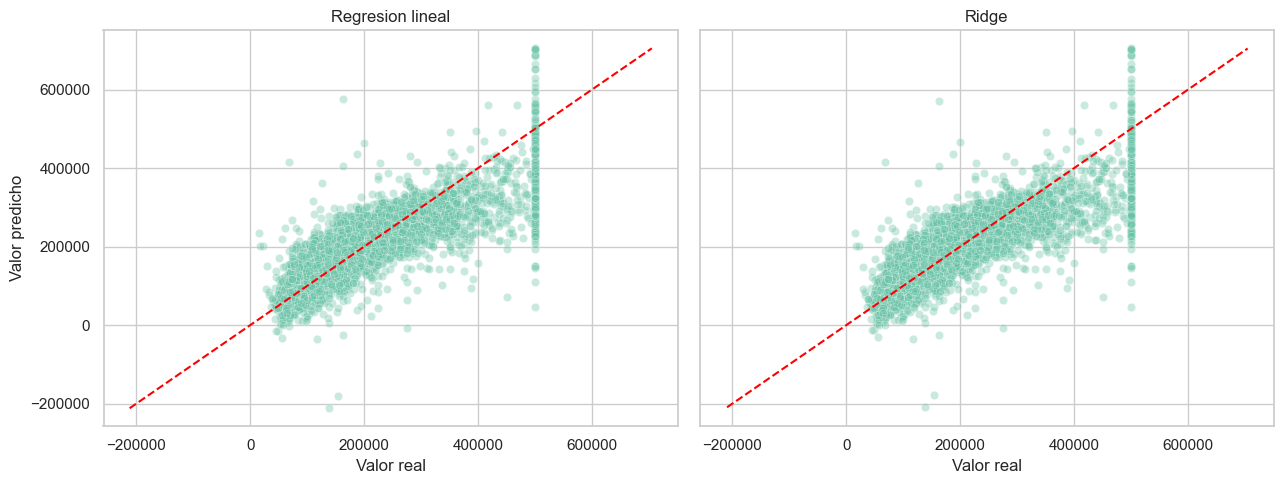

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, title, pred in [
    (axes[0], "Regresion lineal", linear_pred),
    (axes[1], "Ridge", ridge_pred),
]:
    sns.scatterplot(x=y_test, y=pred, alpha=0.35, ax=ax)
    min_value = min(y_test.min(), pred.min())
    max_value = max(y_test.max(), pred.max())
    ax.plot([min_value, max_value], [min_value, max_value], "r--")
    ax.set_title(title)
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Valor predicho")

plt.tight_layout()
plt.show()

Tambien revisamos la distribucion de los errores o residuos. Un residuo es `valor real - valor predicho`. Si los residuos estan muy sesgados o tienen patrones, el modelo puede estar dejando estructura sin capturar.

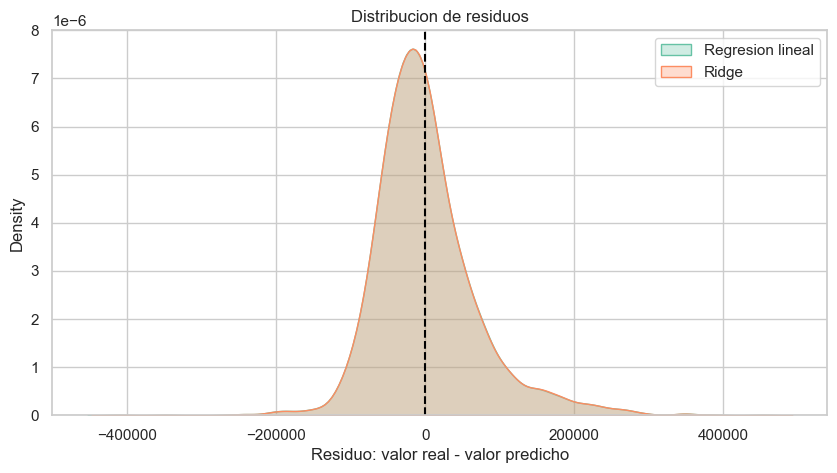

In [23]:
residuals_linear = y_test - linear_pred
residuals_ridge = y_test - ridge_pred

plt.figure(figsize=(10, 5))
sns.kdeplot(residuals_linear, label="Regresion lineal", fill=True, alpha=0.3)
sns.kdeplot(residuals_ridge, label="Ridge", fill=True, alpha=0.3)
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribucion de residuos")
plt.xlabel("Residuo: valor real - valor predicho")
plt.legend()
plt.show()

## 9. Comparacion de modelos

Comparamos los modelos usando las metricas del conjunto de prueba. En MAE, MSE y RMSE, valores menores son mejores. En R², valores mayores son mejores.

Tambien revisamos la diferencia entre desempeno de entrenamiento y prueba. Si el modelo funciona muy bien en entrenamiento pero mucho peor en prueba, podria haber sobreajuste. Si funciona mal en ambos, podria haber bajo ajuste.

,train_rmse,test_mae,test_mse,test_rmse,train_r2,test_r2
modelo,,,,,,
Regresion lineal,67593.21,49645.49,4.778547e+09,69127.04,0.66,0.64
Ridge,67609.46,49667.73,4.784623e+09,69170.97,0.66,0.63


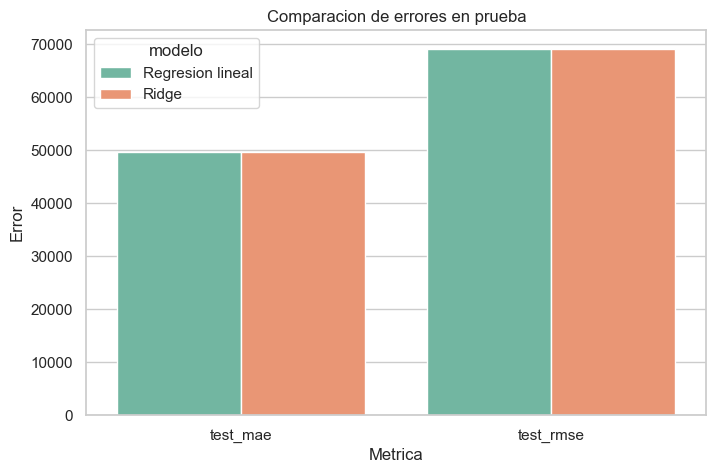

In [24]:
display(results.round(2))

comparison_plot = results[["test_mae", "test_rmse"]].reset_index().melt(
    id_vars="modelo", var_name="metrica", value_name="valor"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_plot, x="metrica", y="valor", hue="modelo")
plt.title("Comparacion de errores en prueba")
plt.xlabel("Metrica")
plt.ylabel("Error")
plt.show()

Seleccionamos automaticamente el modelo con menor RMSE en prueba. Esta es una decision razonable cuando queremos penalizar errores grandes en precios de vivienda.

In [25]:
best_model_name = results["test_rmse"].idxmin()
best_rmse = results.loc[best_model_name, "test_rmse"]
best_r2 = results.loc[best_model_name, "test_r2"]

print(f"Mejor modelo segun RMSE de prueba: {best_model_name}")
print(f"RMSE de prueba: {best_rmse:,.2f}")
print(f"R2 de prueba: {best_r2:.3f}")

for model_name in results.index:
    gap_rmse = results.loc[model_name, "test_rmse"] - results.loc[model_name, "train_rmse"]
    gap_r2 = results.loc[model_name, "train_r2"] - results.loc[model_name, "test_r2"]
    print(f"{model_name}: diferencia RMSE prueba-entrenamiento = {gap_rmse:,.2f}; diferencia R2 entrenamiento-prueba = {gap_r2:.3f}")

Mejor modelo segun RMSE de prueba: Regresion lineal
RMSE de prueba: 69,127.04
R2 de prueba: 0.635
Regresion lineal: diferencia RMSE prueba-entrenamiento = 1,533.83; diferencia R2 entrenamiento-prueba = 0.023
Ridge: diferencia RMSE prueba-entrenamiento = 1,561.51; diferencia R2 entrenamiento-prueba = 0.023


Interpretacion de ajuste:

- Si la diferencia entre entrenamiento y prueba es pequena, el modelo generaliza de forma razonable.
- Si el error de prueba es mucho mayor que el de entrenamiento, hay indicios de sobreajuste.
- Si ambos errores son altos, el modelo puede ser demasiado simple para capturar relaciones complejas del mercado de vivienda.

## 10. Interpretacion de coeficientes

Como usamos modelos lineales, podemos revisar coeficientes. Debido al escalado, los coeficientes numericos se pueden comparar mejor entre si. En variables categoricas codificadas con One-Hot Encoding, cada coeficiente representa el efecto asociado a una categoria frente a la referencia implicita del modelo.

Un coeficiente positivo indica que, manteniendo las demas variables constantes, valores mayores de esa variable se asocian con mayor precio predicho. Un coeficiente negativo indica asociacion con menor precio predicho.

In [26]:
feature_names = ridge_model.named_steps["preprocess"].get_feature_names_out()
ridge_coefficients = pd.Series(
    ridge_model.named_steps["model"].coef_,
    index=feature_names,
).sort_values(key=np.abs, ascending=False)

ridge_coefficients.head(15)

numeric__median_income                     78906.749566
numeric__latitude                         -55807.275933
numeric__longitude                        -55471.232848
numeric__population                       -45951.318377
numeric__households                        38991.426942
categorical__ocean_proximity_ISLAND        37380.702925
categorical__ocean_proximity_INLAND       -35352.847400
numeric__bedrooms_per_room                 16728.748858
numeric__housing_median_age                14154.991323
numeric__rooms_per_household                7567.844982
numeric__total_bedrooms                     6279.976152
numeric__total_rooms                        5804.778647
categorical__ocean_proximity_NEAR BAY      -5229.516252
categorical__ocean_proximity_NEAR OCEAN     3167.655804
numeric__population_per_household            712.363392
dtype: float64

Graficamos los coeficientes mas importantes en valor absoluto. Esto permite identificar que variables tienen mayor influencia dentro del modelo Ridge. La interpretacion debe hacerse con cuidado: los coeficientes muestran asociacion en el modelo, no causalidad.

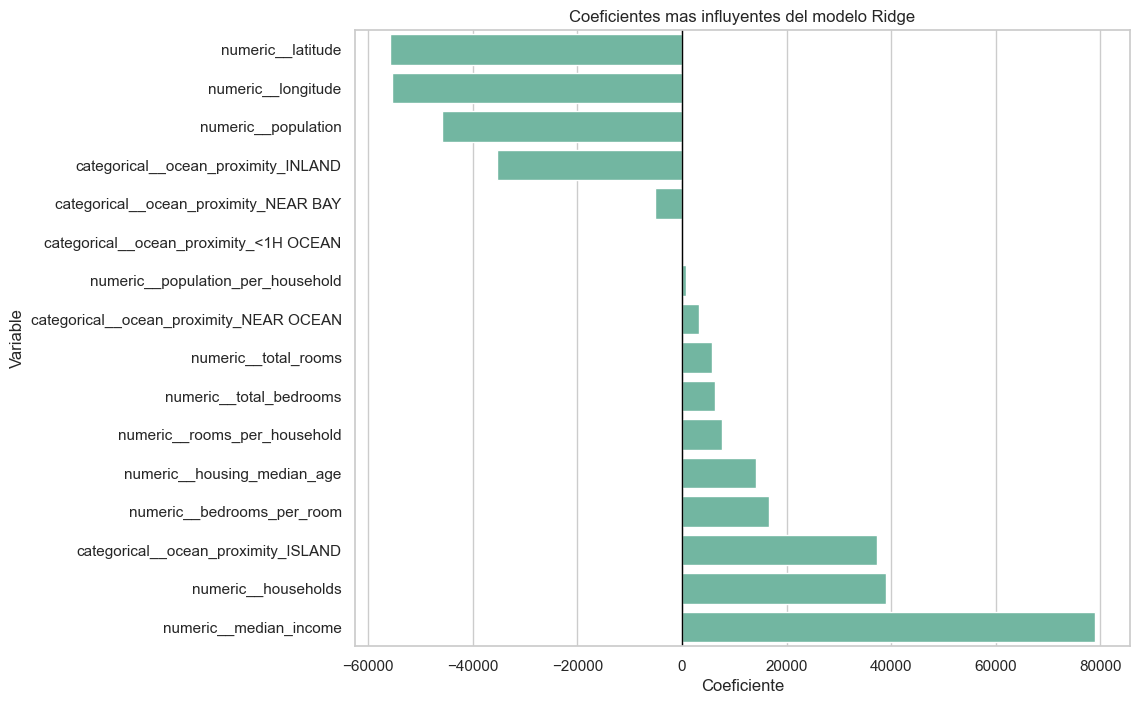

In [27]:
top_coefficients = pd.concat([
    ridge_coefficients.head(10),
    ridge_coefficients.tail(10),
]).sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=top_coefficients.values, y=top_coefficients.index)
plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficientes mas influyentes del modelo Ridge")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

Relacion con el contexto:

- Variables como `median_income` suelen aparecer con influencia positiva, porque zonas con mayores ingresos tienden a tener viviendas de mayor valor.
- Variables geograficas y de cercania al oceano capturan diferencias espaciales del mercado inmobiliario.
- Variables como densidad poblacional o habitaciones por hogar pueden reflejar caracteristicas urbanas, tamano de vivienda y condiciones del distrito.

La interpretacion es util para explicar el modelo, pero no prueba relaciones causales.

## 11. Conclusiones

En este notebook construimos un flujo completo de regresion para predecir precios de vivienda.

Aprendizajes principales:

- Un problema es de regresion cuando la variable objetivo es numerica continua.
- La exploracion inicial ayuda a detectar valores faltantes, escalas distintas y relaciones relevantes.
- Las variables categoricas deben codificarse antes de entrenar modelos lineales.
- El escalado es importante cuando usamos modelos con regularizacion como Ridge.
- Los pipelines ayudan a organizar el flujo y reducen el riesgo de fuga de informacion.
- MAE, MSE, RMSE y R² ofrecen perspectivas complementarias sobre el error del modelo.

Limitaciones:

- Los modelos lineales capturan relaciones principalmente lineales; el mercado inmobiliario puede tener patrones no lineales complejos.
- La variable objetivo parece tener un techo en algunos valores altos, lo cual limita la precision en viviendas muy costosas.
- El dataset esta agregado por distritos, no por viviendas individuales.
- Las relaciones encontradas son asociativas, no necesariamente causales.

Posibles mejoras:

- Ajustar `alpha` de Ridge con validacion cruzada.
- Probar Lasso para seleccion de variables.
- Entrenar modelos no lineales como Random Forest, Gradient Boosting o XGBoost.
- Transformar la variable objetivo con logaritmo si se desea reducir asimetria.
- Crear mas variables geograficas o socioeconomicas.
- Evaluar el desempeno por segmentos, por ejemplo zonas costeras versus zonas interiores.